Barclays Banks Churn **Analysis**

###Project Objective
 - Barclays Bank Facing high customer churn rate, and customer not keep using services,being a data sceientist you task is to identify the companies problem so that they can get real time insights and management can take decision accordingly, Previously banks were not getting timeely insights and did not take decision timely, that cost high customer churn rate , the previous methadologies were old and not upto dated, presently bank needs live analysis and corrective measures to predict the future churn rates and live analysis

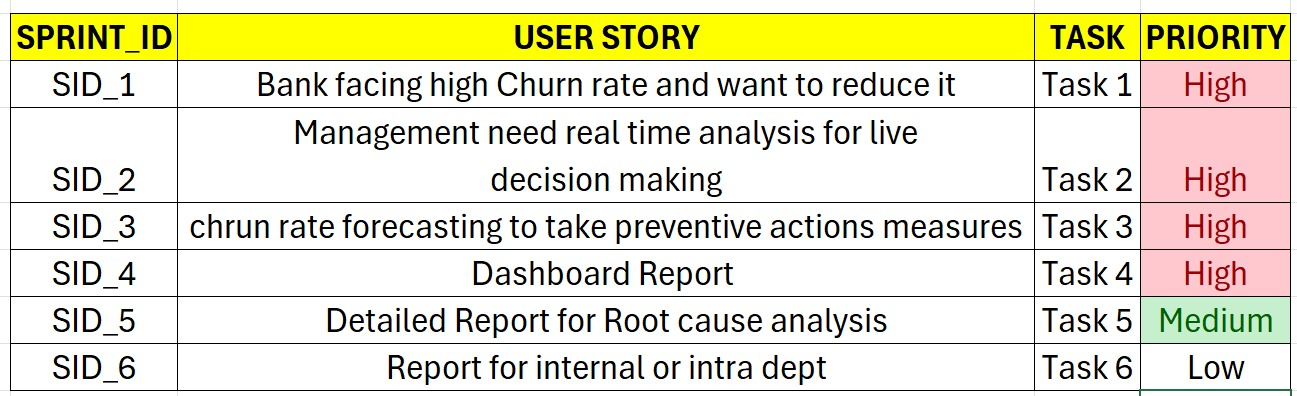

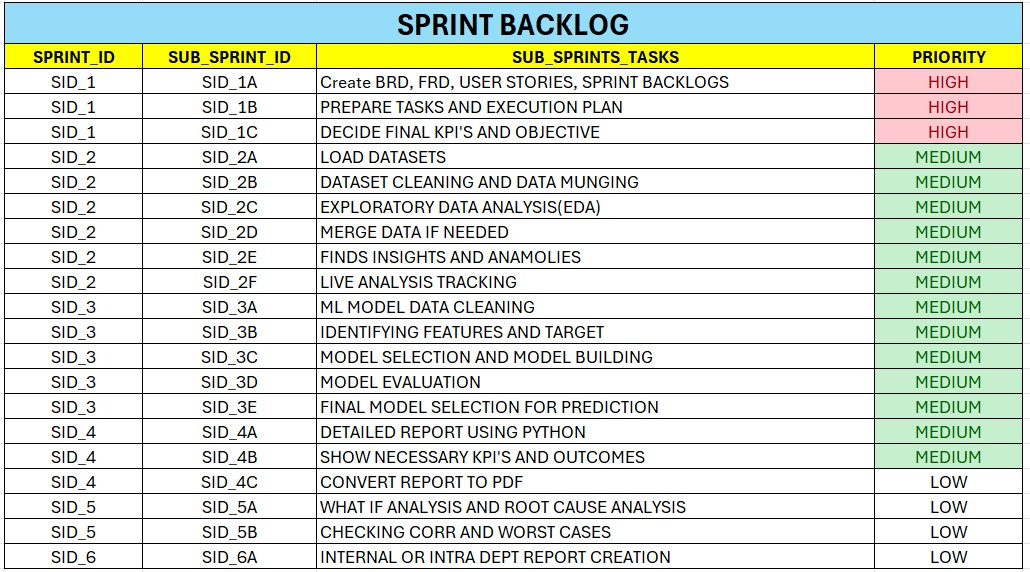

## Step 1: Load Important Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score,recall_score
import pickle
import IPython as ip
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')
print("All Modules Loaded Successfully!!")

All Modules Loaded Successfully!!


Step-2 Load Datasets


In [2]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ActiveCustomer.xlsx"
active_customer_df= pd.read_excel(url)
print("Done")

Done


In [3]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CreditCard.xlsx"
Credit_Card_df = pd.read_excel(url)
print("Done")

Done


In [4]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ExitCustomer.xlsx"
Exit_Customer_df= pd.read_excel(url)
print("Done")

Done


In [5]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Gender.xlsx"
Gender_df = pd.read_excel(url)
print("Done")

Done


In [6]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Geography.xlsx"
Geography_df = pd.read_excel(url)
print("Done")

Done


In [7]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Bank_Churn.csv"
Bank_Churn_df = pd.read_csv(url)
print("Done")

Done


In [8]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CustomerInfo.csv"
Customer_info_df = pd.read_csv(url)
print("Done")

Done


In [14]:
all_dfs = [active_customer_df , Credit_Card_df,
           ExitCustomer_df ,
           Gender_df ,
           Geography_df ,
           Bank_Churn_df ,
           Customer_info_df]

for i in all_dfs:
  print('='*50)
  display(i.sample(2))


NameError: name 'ExitCustomer_df' is not defined

## STEP3: EDA(Exploratory Data Analytics)

In [15]:
# step 3.1 show  bank_churn_df sample
Bank_Churn_df.sample(5)

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
4089,4090,15596979,662,1,2,47,4,0.00,2,1,1,129392.75,0,11-12-2018
4296,4297,15702788,775,1,1,40,5,126212.64,1,1,0,70196.57,0,21-06-2018
7339,7340,15670646,499,2,2,42,7,147187.84,1,1,1,14868.94,1,14-06-2016
4091,4092,15635097,599,3,1,39,6,188976.89,2,0,1,176142.09,0,15-04-2017
4972,4973,15612524,643,3,1,41,5,127841.52,1,1,0,172363.41,0,23-05-2018


In [16]:
# Step 3.2: show df shape size
Bank_Churn_df.shape

#14 columns and 10k rows

(10000, 14)

In [ ]:
Bank_Churn_df.size

In [17]:
# step 3.3: combine all dfs
merged_df = pd.merge(Bank_Churn_df, Customer_info_df, on = 'CustomerId')
merged_df = pd.merge(merged_df, Geography_df, on = 'GeographyID')
final_df = pd.merge(merged_df, Gender_df, on = 'GenderID')
final_df

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory
0,1,15634602,619,1,2,42,7,0.00,1,1,1,101348.88,1,23-03-2016,Hargrave,France,Female
1,2,15647311,608,2,2,41,4,83807.86,1,0,1,112542.58,0,09-10-2018,Hill,Spain,Female
2,3,15619304,502,1,2,42,4,159660.80,3,1,0,113931.57,1,25-03-2019,Onio,France,Female
3,4,15701354,699,1,2,39,3,0.00,2,0,0,93826.63,0,24-10-2019,Boni,France,Female
4,5,15737888,850,2,2,43,3,125510.82,1,1,1,79084.10,0,22-11-2019,Mitchell,Spain,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,1,1,39,5,0.00,2,1,0,96270.64,0,25-03-2018,Obijiaku,France,Male
9996,9997,15569892,516,1,1,35,5,57369.61,1,1,1,101699.77,0,17-06-2018,Johnstone,France,Male
9997,9998,15584532,709,1,2,36,5,0.00,1,0,1,42085.58,1,18-03-2018,Liu,France,Female
9998,9999,15682355,772,3,1,42,3,75075.31,2,1,0,92888.52,1,12-11-2019,Sabbatini,Germany,Male


In [19]:
final_df.shape

(10000, 17)

In [18]:
#show column info
#step 3.4
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [20]:
#step 3.5 : Drop Nan or missing values
final_df.dropna(inplace=True)
print("Done")

Done


In [21]:
#step 3.6 show data stats
final_df.describe(include = 'number')

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,1.749500,1.454300,38.921800,4.86430,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,0.830433,0.497932,10.487806,1.21525,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,1.000000,1.000000,18.000000,3.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,1.000000,1.000000,32.000000,4.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,1.000000,1.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,3.000000,2.000000,44.000000,6.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,3.000000,2.000000,92.000000,7.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [22]:
#step 3.7: show categorical data stats
final_df.describe(include = 'object')

,Bank DOJ,Surname,GeographyLocation,GenderCategory
count,10000,10000,10000,10000
unique,1332,2932,3,2
top,16-12-2017,Smith,France,Male
freq,35,32,5014,5457


In [23]:
#step 3.8: show data correlation
corr = final_df.corr(numeric_only=True)
corr
#corr range form
#-1 to +1
#-1:represents:highly negative correlation
#+1:represent: highly positively correlation
#0:represents: no correlation


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,-0.005196,-0.018196,0.000783,0.002901,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.000821,0.002641,0.009497,0.003884,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,0.008267,0.002857,-0.003965,-0.007355,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
GeographyID,-0.005196,0.000821,0.008267,1.000000,0.016936,0.048092,-0.003858,0.348700,-0.006180,0.004036,-0.012692,0.007382,0.153771
GenderID,-0.018196,0.002641,0.002857,0.016936,1.000000,0.027544,-0.008018,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512
Age,0.000783,0.009497,-0.003965,0.048092,0.027544,1.000000,0.010788,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.002901,0.003884,-0.007355,-0.003858,-0.008018,0.010788,1.000000,0.001457,-0.029927,0.003857,-0.007576,0.005744,0.000699
Balance,-0.009067,-0.012419,0.006268,0.348700,-0.012087,0.028308,0.001457,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.006180,0.021859,-0.030680,-0.029927,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,0.004036,-0.005766,-0.011721,0.003857,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138


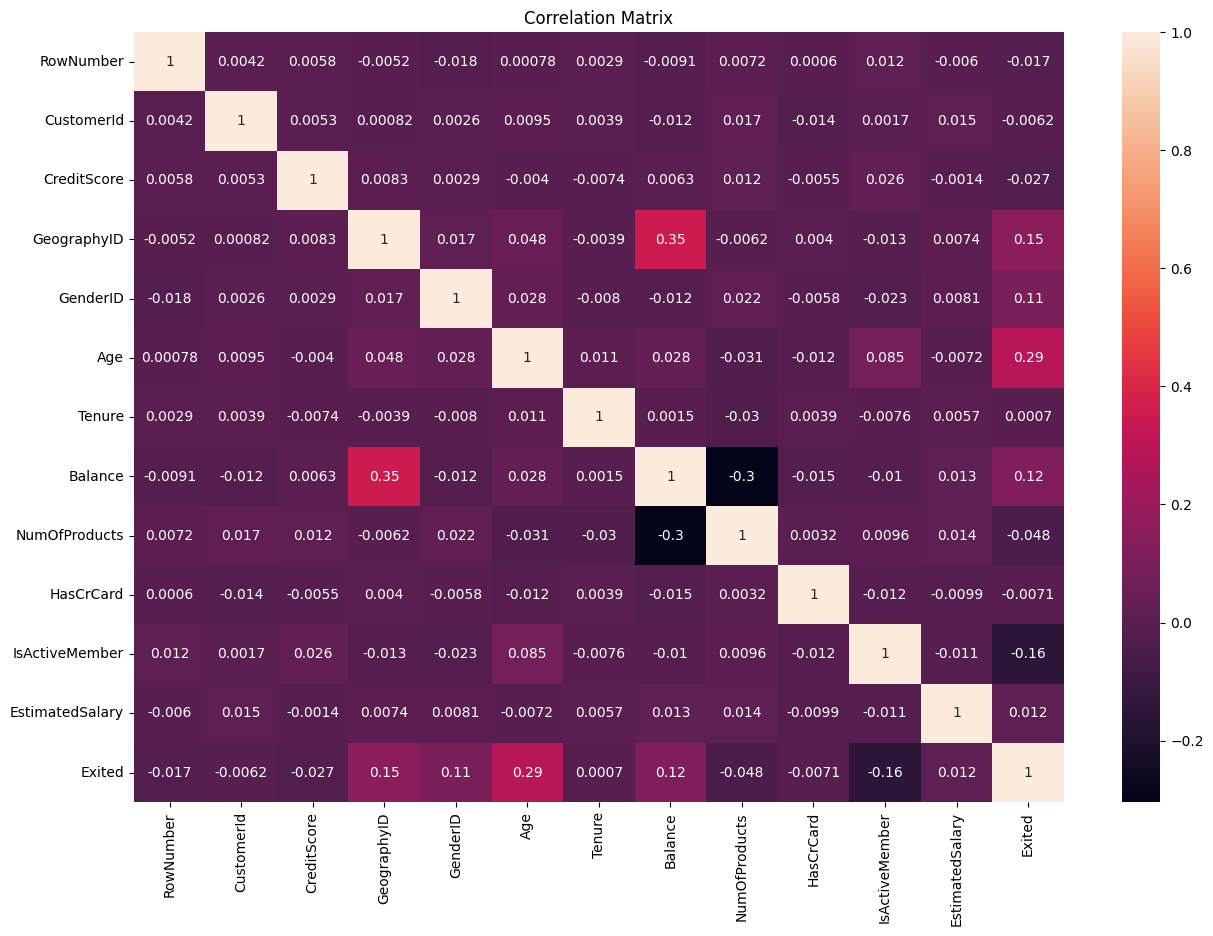

In [24]:
# Step 3.9:
plt.figure(figsize = (15,10))
plt.title("Correlation Matrix")
sns.heatmap(corr,annot = True)
plt.show()

In [29]:
# Step 3.10: Divide Columns into required objects

textual_columns = final_df.select_dtypes('object').columns
numerical_columns = final_df.select_dtypes('number').columns
print("textual Columns:\n",textual_columns)
print('='*100)
print("Numerical Columns: \n",numerical_columns)

textual Columns:
 Index(['Surname', 'GeographyLocation', 'GenderCategory'], dtype='object')
Numerical Columns: 
 Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [26]:
# Step 3.11: Change Bank DOJ to datetime Dtype
final_df['Bank DOJ'] = pd.to_datetime(final_df['Bank DOJ'])
print("Done")

Done


In [27]:
# Step 3.12: Drop unwanted column
final_df.drop('RowNumber', axis = 1, inplace= True)
# axis= 1: means: drop column, axis:0 : drop row
#inplace= True: means: apply changes in original dataset
print("Done")

Done


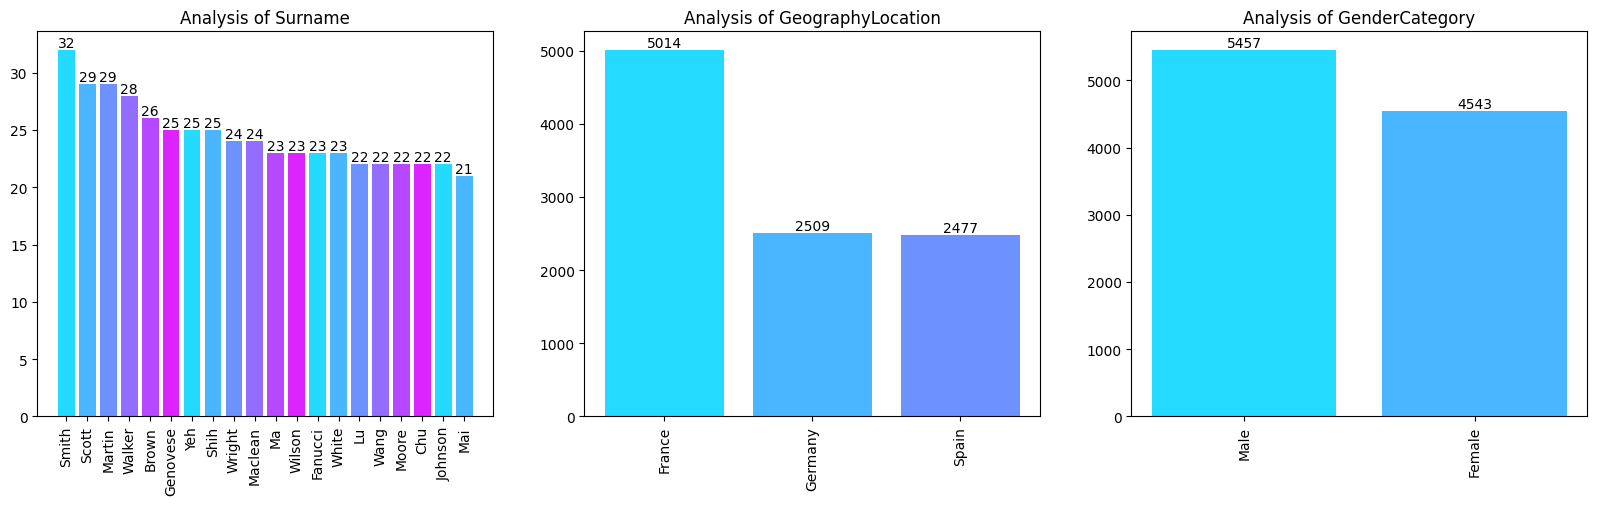

In [30]:
# Step 3.13: Univariate Analysis
# means: single columns analysis

plt.figure(figsize = (20,5))
for i ,j in enumerate(textual_columns):
  plt.subplot(1,3,i+1)
  temp_df =  final_df[j].value_counts().head(20)
  x= temp_df.index
  y= temp_df.values
  plt.title(f"Analysis of {j}")
  ax = plt.bar(x,y,color = sns.color_palette('cool'))
  plt.bar_label(ax)
  plt.xticks(rotation = 90)
plt.show()

  #plt.show: out of loop hai
  #subplot: plot multiple plots at once
  # i: is index
  # j: is column name
  # enumerate:to get index and value at same time
  # value counts: to grouped data and count its value frequency
  # sns.color_paletter: to change color shades

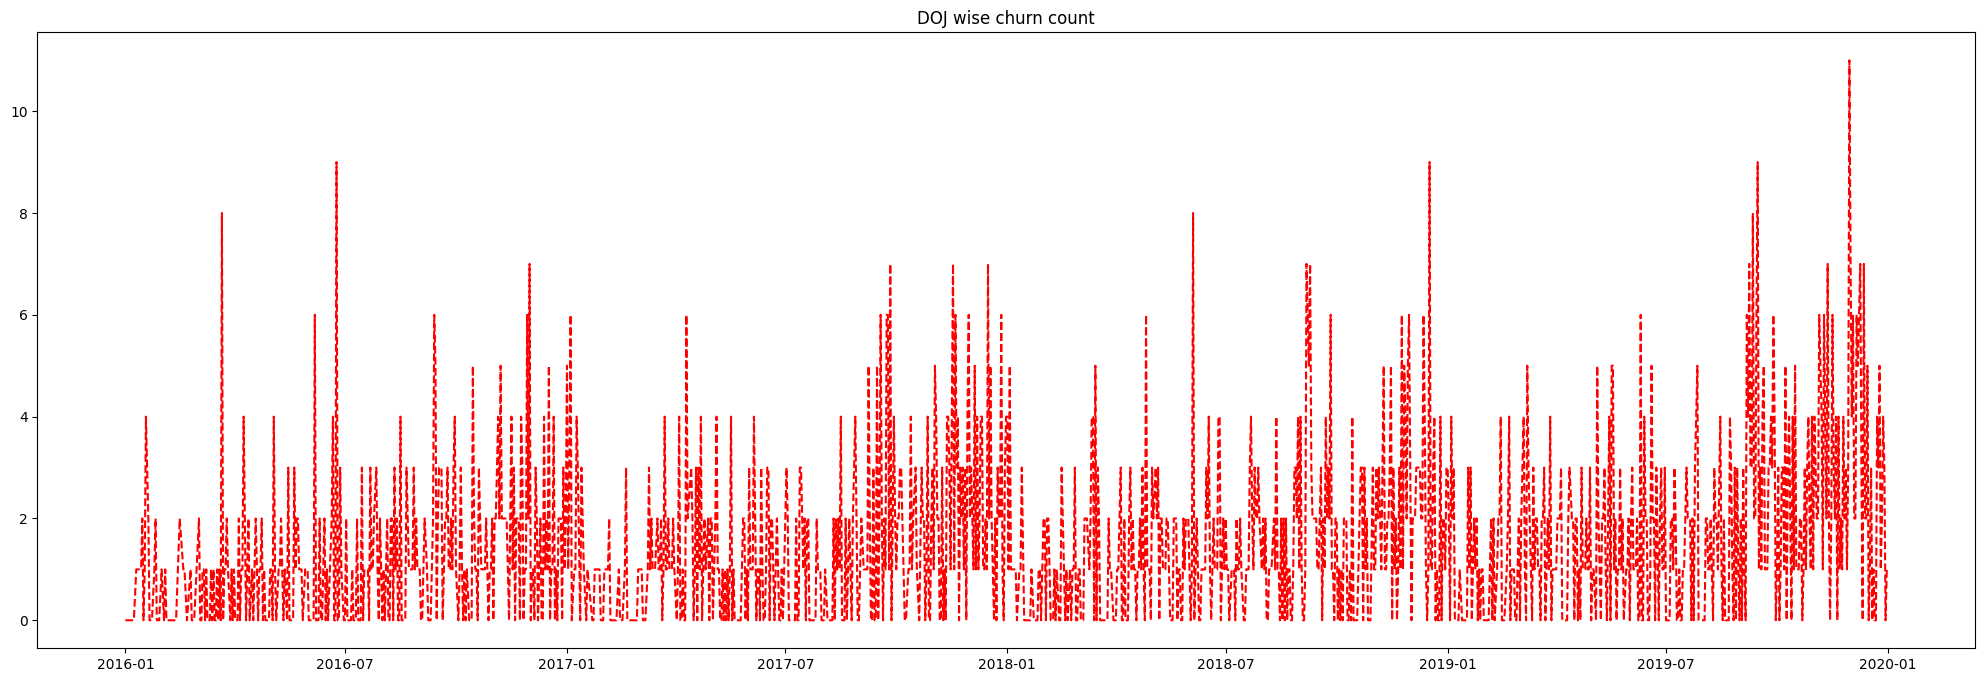

In [31]:
# Step 3.14: Bivariate Analysis
# Show Bank DOJ wise churn count

plt.figure(figsize = (25,8))
plt.title("DOJ wise churn count")
temp_df = final_df.groupby('Bank DOJ')['Exited'].sum()
x= temp_df.index
y= temp_df.values
plt.plot(x,y,color ='r' ,linestyle='--')
plt.show()

In [32]:
#step 3.15 :create new column for monthly and weekly analysis
final_df['Month']=final_df['Bank DOJ'].dt.month_name()
final_df['Day']=final_df['Bank DOJ'].dt.day_name()

#.dt: means:datetime
final_df.sample()

,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
6105,15605134,617,1,2,34,7,131244.65,2,1,0,183229.02,0,2016-04-17,Bond,France,Female,April,Sunday


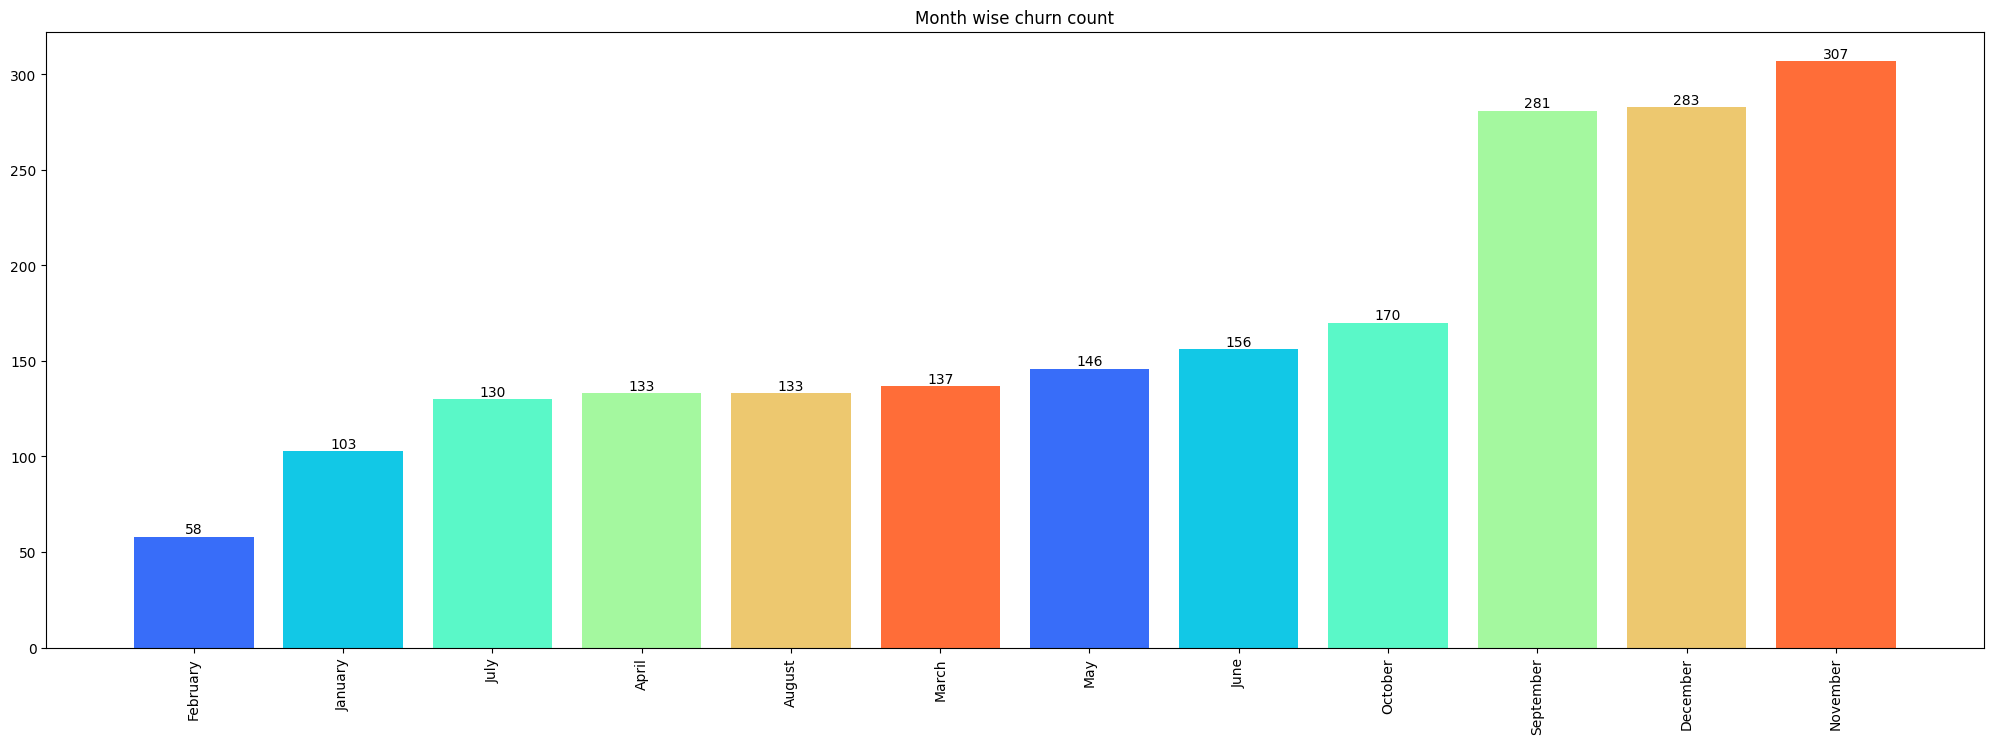

In [33]:
# step 3.16:: Show Monthly Churn Analysis

plt.figure(figsize = (25,8))
plt.title("Month wise churn count")
temp_df = final_df.groupby('Month')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x,y,color = sns.color_palette('rainbow'))
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.show()

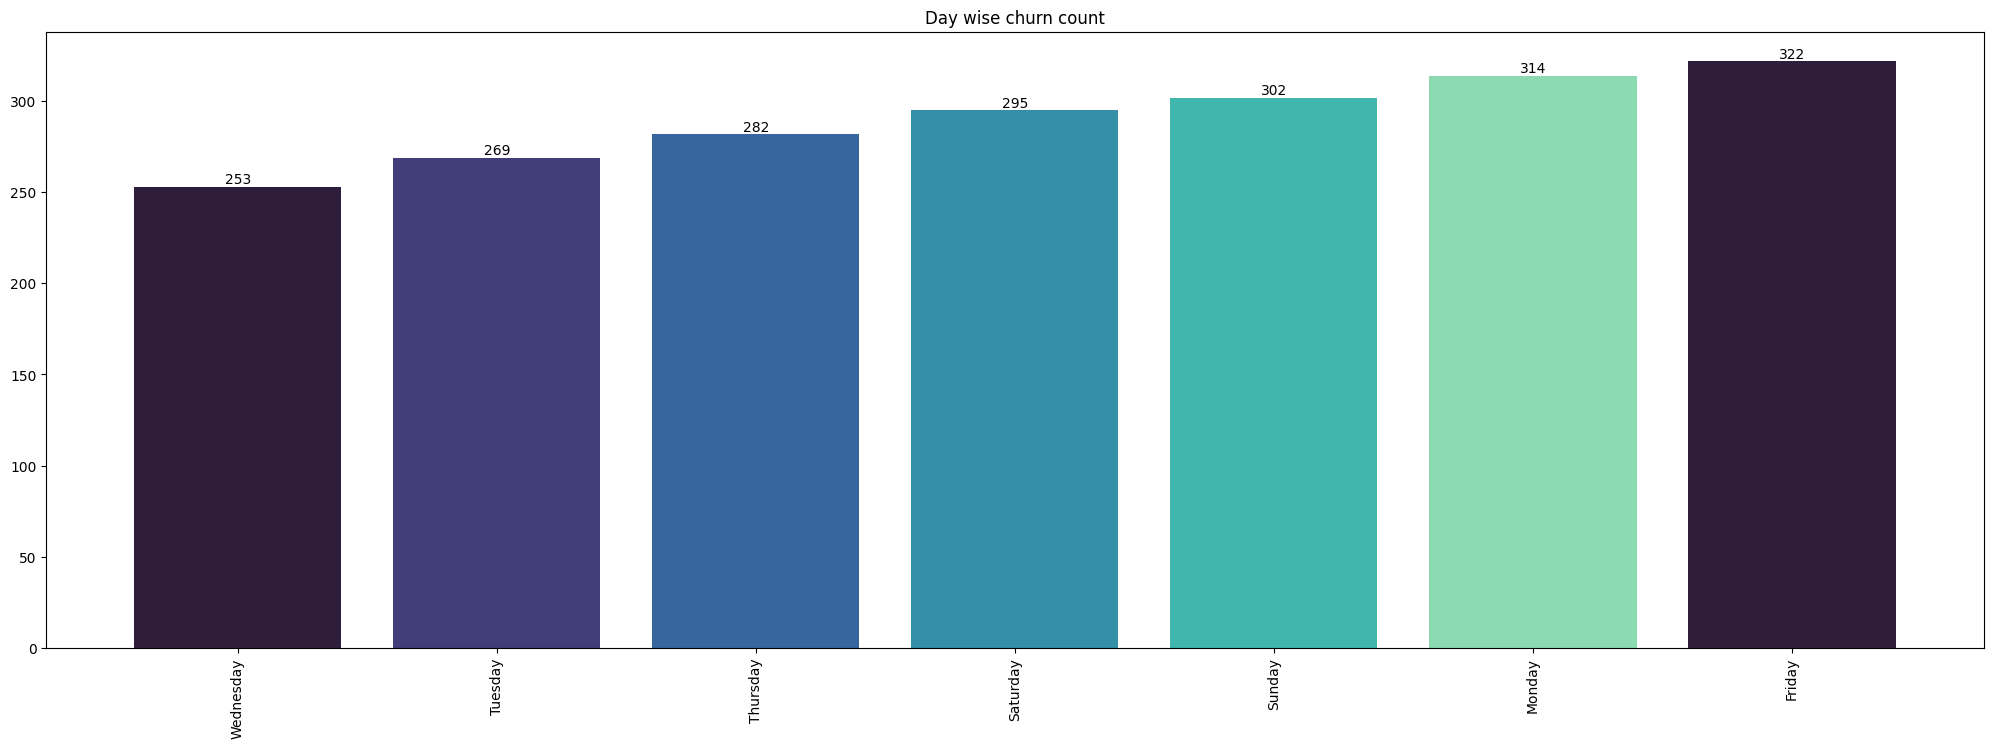

In [34]:
# step 3.16:: Show Day wise Churn Analysis

plt.figure(figsize = (25,8))
plt.title("Day wise churn count")
temp_df = final_df.groupby('Day')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x,y,color = sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.show()

In [36]:
#3.18 : gender wise churn analysis
#3.19 : GeographyLocation wise churn analysis
#3.20: Tenure wise churn analysis

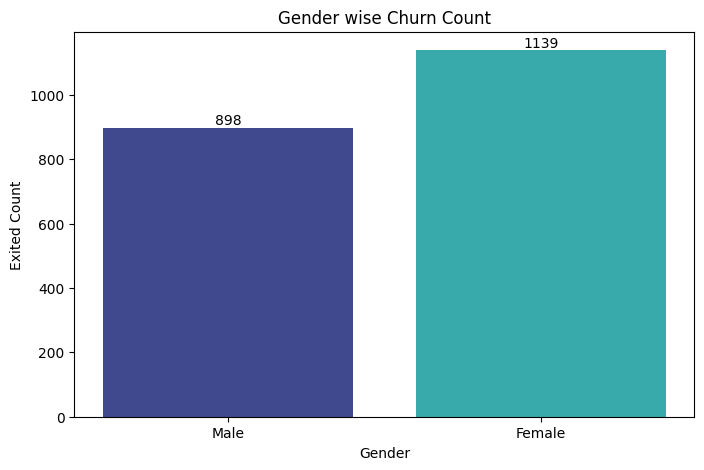

In [35]:
# Step 3.18: Gender wise churn analysis
plt.figure(figsize=(8, 5))
plt.title("Gender wise Churn Count")
temp_df = final_df.groupby('GenderCategory')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x, y, color=sns.color_palette('mako', len(x)))
plt.bar_label(ax)
plt.xlabel("Gender")
plt.ylabel("Exited Count")
plt.show()

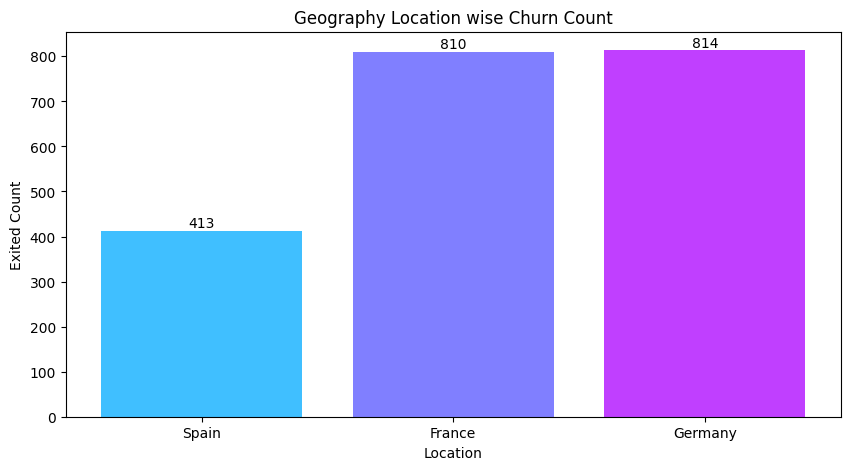

In [37]:
# Step 3.19: Show Geography/Location Churn Analysis
plt.figure(figsize=(10, 5))
plt.title("Geography Location wise Churn Count")
temp_df = final_df.groupby('GeographyLocation')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x, y, color=sns.color_palette('cool', len(x)))
plt.bar_label(ax)
plt.xlabel("Location")
plt.ylabel("Exited Count")
plt.show()

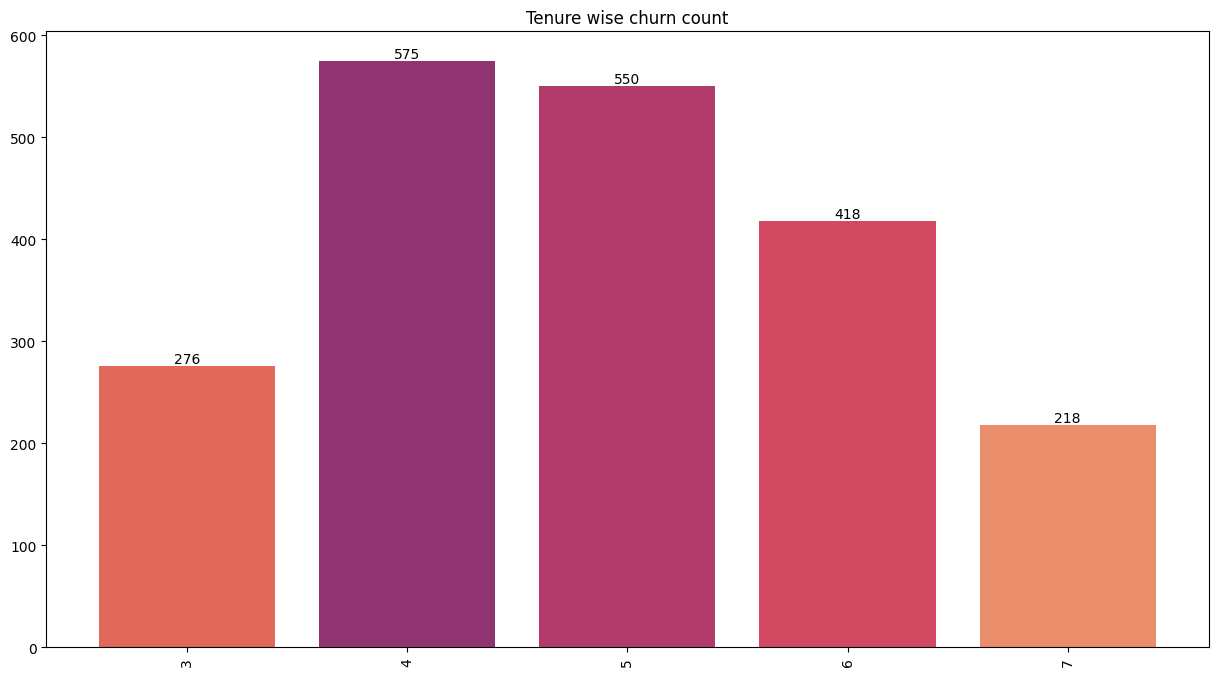

In [38]:
# Step 3.20: Show Tenure Churn Analysis
plt.figure(figsize = (15,8))
plt.title("Tenure wise churn count")
temp_df = final_df.groupby('Tenure')['Exited'].sum().sort_values()
x= temp_df.index
y= temp_df.values
ax = plt.bar(x,y,color = sns.color_palette('flare'))
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.show()

In [41]:
final_df.sample()

,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
8677,15757829,609,3,2,40,7,137389.77,2,1,0,170122.22,0,2016-07-08,Timperley,Germany,Female,July,Friday


In [40]:
# step 3.21 Remove unwanted cols for ml model
ml_drop_columns = ['CustomerId' , 'GeographyID' , 'GenderID' , 'Bank DOJ' , 'Surname' , 'Day']
ml_df = final_df.drop(ml_drop_columns , axis = 1 ,inplace= False)
ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
3251,850,43,4,108508.82,3,1,0,184044.8,1,Germany,Male,September


#Step 4 : Feature Engineering
- ML onlyorks with numerical data , if we are getting any textuual data
- we need to convert textual data to numerical
- technique is called feature engineering
- here geographyLocation , GendorCategory or Month textual in nature

In [39]:
# types of technique
# OHE: one hot encoding
#map: using dict
# apply lambda method
# caegorical encoding
# get dummies
# ordinal encoding
#TF-IDF
#BOW - bag of words
# advance : countvectorizer , word embeddings
# more advance : vector database using cosine technique

In [42]:
# Step 4.1:
import calendar
months_name = list(calendar.month_name)[1:]
index = list(range(len(months_name)))
map = dict(zip(months_name,index))

ml_df['Month'] = ml_df['Month'].map(map)
ml_df.sample()

# zip: bind two object together and give dict
# .map: method to map the key with value



,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
2565,705,50,7,77065.9,2,0,1,145159.26,0,France,Female,4


In [43]:
ml_df['GenderCategory'].unique()

array(['Female', 'Male'], dtype=object)

In [44]:
ml_df['GenderCategory'] = ml_df['GenderCategory'].map({'Male':0,'Female':1})
ml_df['GeographyLocation']=ml_df['GeographyLocation'].map({'Spain':1,'France':1,'Germany':0})
ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
1271,723,42,5,99095.73,1,1,1,17512.53,0,1,0,5


In [45]:
# Step 4.2: Show target vs feature corr
ml_df.corr()['Exited'].sort_values(ascending = False)

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
GenderCategory,0.106512
EstimatedSalary,0.012097
Month,0.002312
Tenure,0.000699
HasCrCard,-0.007138
CreditScore,-0.027094
NumOfProducts,-0.047820


#STEP 5 : Divide Data im features vs target

In [46]:
X = ml_df.drop('Exited',axis = 1)
y = ml_df['Exited']

#x: must be capital and in dataframe
#y: must be small and in series
print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


#STEP 6 : Divide the data into train and test

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
print("X_train-shape:",X_train.shape)
print("X_test-shape:",X_test.shape)
print("y_train-shape:",y_train.shape)
print("y_test-shape:",y_test.shape)

X_train-shape: (8000, 11)
X_test-shape: (2000, 11)
y_train-shape: (8000,)
y_test-shape: (2000,)
